### Análisis de Rendimiento Académico y Riesgo de Abandono

`Status: Done`

A través del uso de Python en Google Colab, se busca transformar datos en información útil que apoye la toma de decisiones académicas.

In [17]:
# =========================
# 1. Importar librerías
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# =========================
# 2. Cargar dataset
# =========================
df = pd.read_csv('../dataset/cleaned/cl_dataset_unicaribe.csv', encoding="latin-1")

print("\nInformación general:")
print("-------------")
print(df.info())
print("-------------")
print("Primeras filas:")
print("-------------")
df.head()


Información general:
-------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edad                  1000 non-null   int64  
 1   genero                1000 non-null   object 
 2   carrera               1000 non-null   object 
 3   materias_inscritas    1000 non-null   int64  
 4   horas_estudio_semana  1000 non-null   int64  
 5   asistencia            1000 non-null   float64
 6   uso_plataformas       1000 non-null   object 
 7   gpa                   1000 non-null   float64
 8   trabajo               1000 non-null   int64  
 9   internet              1000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 78.3+ KB
None
-------------
Primeras filas:
-------------


,edad,genero,carrera,materias_inscritas,horas_estudio_semana,asistencia,uso_plataformas,gpa,trabajo,internet
0,23,M,Medicina,4,11,72.1,Microsoft Teams,2.57,0,1
1,31,F,Comunicación Social,6,28,75.6,Moodle,3.07,0,0
2,27,M,Arquitectura,6,14,72.1,Google Classroom,2.13,0,1
3,24,M,Turismo,5,17,57.6,Zoom,2.07,1,1
4,23,M,Contaduría Pública,5,22,88.5,Blackboard,3.05,0,1


In [18]:
# =========================
# 3. Creamos una columna de rendimiento académico basada en el GPA
# =========================

def clasificar_rendimiento(gpa):
    if gpa >= 3.5:
        return 'Alto'
    elif gpa >= 2.5:
        return 'Medio'
    elif gpa >= 2.0:
        return 'Bajo'
    else:
        return 'Riesgo'

df['rendimiento'] = df['gpa'].apply(clasificar_rendimiento)
df.head()

,edad,genero,carrera,materias_inscritas,horas_estudio_semana,asistencia,uso_plataformas,gpa,trabajo,internet,rendimiento
0,23,M,Medicina,4,11,72.1,Microsoft Teams,2.57,0,1,Medio
1,31,F,Comunicación Social,6,28,75.6,Moodle,3.07,0,0,Medio
2,27,M,Arquitectura,6,14,72.1,Google Classroom,2.13,0,1,Bajo
3,24,M,Turismo,5,17,57.6,Zoom,2.07,1,1,Bajo
4,23,M,Contaduría Pública,5,22,88.5,Blackboard,3.05,0,1,Medio


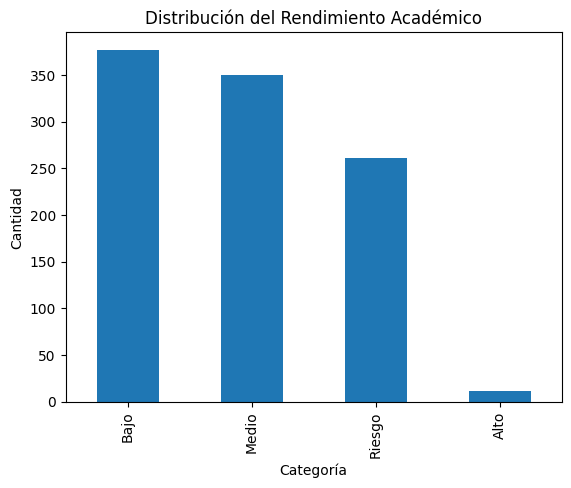

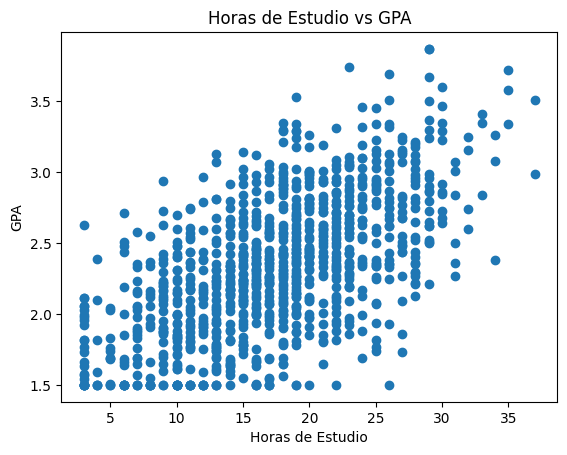

In [19]:
# =========================
# 4. Análisis Exploratorio
# =========================

# Distribución de rendimiento
plt.figure()
df['rendimiento'].value_counts().plot(kind='bar')
plt.title('Distribución del Rendimiento Académico')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.show()

# Relación horas de estudio vs GPA
plt.figure()
plt.scatter(df['horas_estudio_semana'], df['gpa'])
plt.title('Horas de Estudio vs GPA')
plt.xlabel('Horas de Estudio')
plt.ylabel('GPA')
plt.show()


Reporte de Clasificación:
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00         4
        Bajo       1.00      1.00      1.00       120
       Medio       1.00      1.00      1.00       102
      Riesgo       1.00      1.00      1.00        74

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



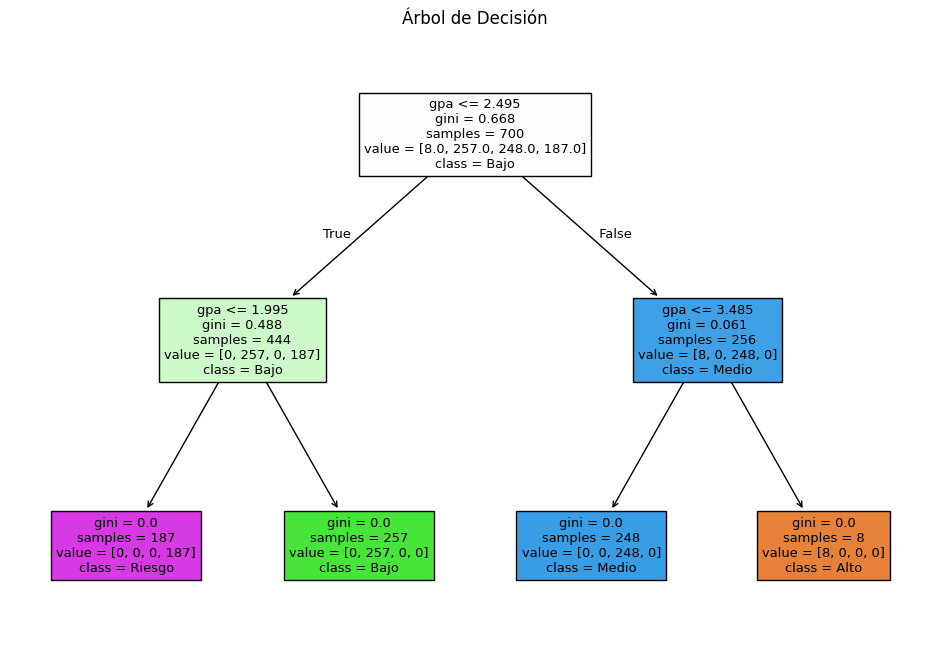

In [20]:
# =========================
# 5. Preparación de datos
# =========================

# Convertir variables categóricas
X = df.drop('rendimiento', axis=1)
X = pd.get_dummies(X)

y = df['rendimiento']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# =========================
# 5. Árbol de Decisión
# =========================

model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

# Predicción
pred = model.predict(X_test)

print("\nReporte de Clasificación:")
print(classification_report(y_test, pred))

# Visualizar árbol
plt.figure(figsize=(12,8))
plot_tree(model, filled=True, feature_names=X.columns, class_names=model.classes_)
plt.title('Árbol de Decisión')
plt.show()

In [21]:
# =========================
# 6. Insights automáticos
# =========================

print("\nINSIGHTS:")
print("-------------")

# Ejemplo simple de insight
if 'asistencia' in df.columns:
    low_attendance = df[df['asistencia'] < 60]
    print(f"Estudiantes con baja asistencia: {len(low_attendance)}")
    print("-------------")

if 'horas_estudio_semana' in df.columns:
    avg_study = df.groupby('rendimiento')['horas_estudio_semana'].mean()
    print("Promedio de horas de estudio por rendimiento:")
    print("-------------")
    print(avg_study)
    print("-------------")

print("\nConclusión: Variables como asistencia y horas de estudio tienen fuerte impacto en el rendimiento.")


INSIGHTS:
-------------
Estudiantes con baja asistencia: 104
-------------
Promedio de horas de estudio por rendimiento:
-------------
rendimiento
Alto      28.916667
Bajo      16.679045
Medio     21.540000
Riesgo    12.348659
Name: horas_estudio_semana, dtype: float64
-------------

Conclusión: Variables como asistencia y horas de estudio tienen fuerte impacto en el rendimiento.


In [22]:
# Ver columnas reales
print(df.columns)

# --- Discretización segura ---
df['asistencia_cat'] = pd.cut(df['asistencia'],
    bins=[-1, 60, 80, 100],
    labels=['baja', 'media', 'alta'])

df['estudio_cat'] = pd.cut(df['horas_estudio_semana'],
    bins=[-1, 5, 10, 50],
    labels=['bajo', 'medio', 'alto'])

# --- Rendimiento ---
def rendimiento(gpa):
    if gpa >= 3.5:
        return 'alto'
    elif gpa >= 2.5:
        return 'medio'
    elif gpa >= 2.0:
        return 'bajo'
    else:
        return 'riesgo'

df['rendimiento'] = df['gpa'].apply(rendimiento)

# --- Selección ---
df_rules = df[['asistencia_cat', 'estudio_cat', 'trabajo', 'rendimiento']]

# eliminar nulos
df_rules = df_rules.dropna()

# --- Convertir a string ---
df_rules = df_rules.astype(str)

# --- Transacciones ---
transactions = df_rules.apply(lambda row: list(row), axis=1)

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# --- Apriori ---
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)

# --- Reglas ---
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# --- Filtrar ---
rules = rules[(rules['lift'] > 1)]

# --- Mostrar ---
print("Reglas encontradas:\n")

if rules.empty:
    print("No se encontraron reglas. Ajusta support o confidence.")
else:
    for _, row in rules.iterrows():
        print(f"SI {set(row['antecedents'])} ENTONCES {set(row['consequents'])}")
        print(f"  soporte: {row['support']:.2f}")
        print(f"  confianza: {row['confidence']:.2f}")
        print(f"  lift: {row['lift']:.2f}")
        print()

Index(['edad', 'genero', 'carrera', 'materias_inscritas',
       'horas_estudio_semana', 'asistencia', 'uso_plataformas', 'gpa',
       'trabajo', 'internet', 'rendimiento'],
      dtype='object')
Reglas encontradas:

SI {'0'} ENTONCES {'alto'}
  soporte: 0.41
  confianza: 0.83
  lift: 1.01

SI {'riesgo'} ENTONCES {'0'}
  soporte: 0.13
  confianza: 0.51
  lift: 1.04

SI {'alta'} ENTONCES {'1'}
  soporte: 0.24
  confianza: 0.53
  lift: 1.03

SI {'medio'} ENTONCES {'1'}
  soporte: 0.25
  confianza: 0.53
  lift: 1.04

SI {'alta'} ENTONCES {'alto'}
  soporte: 0.38
  confianza: 0.84
  lift: 1.02

SI {'medio'} ENTONCES {'alta'}
  soporte: 0.28
  confianza: 0.59
  lift: 1.30

SI {'alta'} ENTONCES {'medio'}
  soporte: 0.28
  confianza: 0.62
  lift: 1.30

SI {'bajo'} ENTONCES {'media'}
  soporte: 0.21
  confianza: 0.50
  lift: 1.13

SI {'riesgo'} ENTONCES {'media'}
  soporte: 0.14
  confianza: 0.56
  lift: 1.25

SI {'0', 'alta'} ENTONCES {'alto'}
  soporte: 0.18
  confianza: 0.84
  lift: 1.02



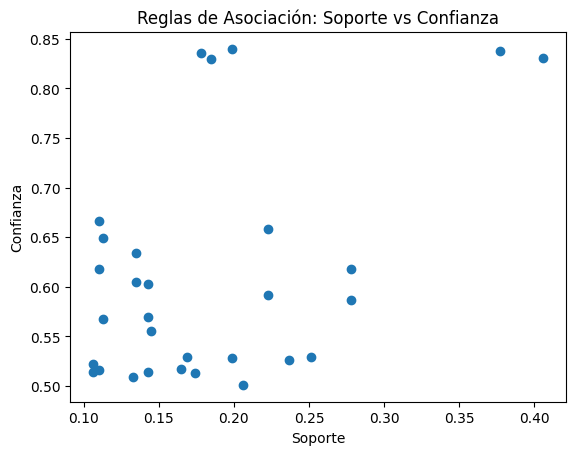

-------------
En esta gráfica observamos cuáles reglas tienen mayor relevancia según soporte y lift.
-------------


In [23]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(rules['support'], rules['confidence'])

plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.title('Reglas de Asociación: Soporte vs Confianza')

plt.show()
print("-------------")
print("En esta gráfica observamos cuáles reglas tienen mayor relevancia según soporte y lift.")
print("-------------")